# Tutorial 4: attention and the Transformer, built by hand
**Deep Learning 89-6877, Fall 2026.** TA: Tal Fiskus.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/idansc/dl-course-2026/blob/main/tutorials/T04_transformers.ipynb)
· [Recap slides (PDF)](https://github.com/idansc/dl-course-2026/blob/main/tutorials/recap/T04_transformers_recap.pdf)

Plan for today (≈ 70 min):
1. Lecture recap: attention as gating, scaled dot-product, multi-head, the block, the 2026 block, ViT (10 min)
2. Scaled dot-product attention, causal mask, multi-head attention (10 min)
3. The modern block: RMSNorm, SwiGLU, RoPE → a char-level mini-GPT on Tiny Shakespeare (15 min)
4. Grouped-query attention and a top-k mixture-of-experts FFN (10 min)
5. Symmetry: attention is permutation-equivariant; positional encoding breaks it (5 min)
6. Patchify + a tiny ViT on CIFAR-10 (10 min)
7. Inside the trained mini-GPT: logit lens and attention sinks (10 min)
8. If time: train the MoE mini-GPT with and without the balancing loss

Runs on CPU (Colab or laptop, ≈ 10 min end to end). Cells marked ✏️ are for you to try.

In [1]:
import math, os, time, urllib.request
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
torch.manual_seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("device:", device, "| torch", torch.__version__)

device: mps | torch 2.14.1


## 1. Lecture recap

**Attention as gating.** Attentive pooling scores each of $n$ elements and returns a weighted sum, $z = \sum_i [g(x)]_i\, x_i$ with $g(x)=\mathrm{softmax}(\cdot)\in\Delta^{n}$. The weights are computed from the data, so the "gate" changes with every input.

**Scaled dot-product attention.** Queries $Q\in\mathbb{R}^{n_q\times d}$, keys $K\in\mathbb{R}^{n_k\times d}$, values $V\in\mathbb{R}^{n_k\times d_v}$:
$$\mathrm{Attn}(Q,K,V)=\mathrm{softmax}\!\Big(\frac{QK^\top}{\sqrt d}\Big)V .$$
The $\sqrt d$ keeps the logits at unit scale: for $q,k$ with i.i.d. unit-variance entries, $\mathrm{Var}(q^\top k)=d$.
**Self-attention:** $Q=XW_Q,\ K=XW_K,\ V=XW_V$ from the same sequence $X$. **Causal (masked)** self-attention sets $E_{ij}=-\infty$ for $j>i$, so token $i$ cannot look ahead (language modeling).

**Multi-head.** $H$ heads of size $d/H$ in parallel, each with its own $W_Q^h,W_K^h,W_V^h$; concatenate and project with $W_O$. Same FLOPs as one head of size $d$.

**Transformer block (2017).** $x \leftarrow \mathrm{LN}(x+\mathrm{MHA}(x))$, $x\leftarrow\mathrm{LN}(x+\mathrm{MLP}(x))$. Attention is the only operation that mixes tokens; norm and MLP act per token.

**The 2026 block** (Llama 3 / Qwen 3 style): same skeleton, with
- **pre-norm**: $x \leftarrow x + \mathrm{Attn}(\mathrm{Norm}(x))$, $x \leftarrow x + \mathrm{FFN}(\mathrm{Norm}(x))$, so the residual stream is never normalized;
- **RMSNorm**: $\mathrm{RMSNorm}(x)=\dfrac{x}{\sqrt{\tfrac1d\sum_i x_i^2+\epsilon}}\odot g$ (no mean-centering, no bias);
- **SwiGLU**: $\mathrm{FFN}(x)=W_2\big(\mathrm{SiLU}(W_1x)\odot W_3x\big)$, hidden size $\approx\tfrac83 d$ to keep the parameter count of a $4d$ MLP;
- **RoPE**: rotate each pair of coordinates of $q$ and $k$ by an angle $m\theta_j$ at position $m$; then $\langle R_m q, R_n k\rangle$ depends only on $n-m$;
- **GQA**: $H$ query heads share $H_{kv}<H$ key/value heads (KV cache $H/H_{kv}$ times smaller);
- **MoE**: replace the FFN by $E$ expert FFNs and a router that sends each token to its top-$k$; an auxiliary loss keeps the experts evenly used.

**Symmetry.** Without positions, self-attention is **permutation-equivariant**: $f(PX)=P\,f(X)$. A sequence is then a set. Positional encoding (learned, sinusoidal or RoPE) breaks this on purpose.

**ViT.** Cut the image into $16\times16$ patches, flatten, project linearly → tokens; add a [CLS] token and learned position embeddings; run a Transformer encoder; classify from [CLS].

## 2. Scaled dot-product attention and multi-head attention

Shapes: `q (B, H, Tq, d)`, `k, v (B, H, Tk, d)`. A boolean `mask` is `True` where attention is **allowed**, as in PyTorch.

In [2]:
def attention(q, k, v, mask=None):
    # returns (output, attention weights)
    scores = q @ k.transpose(-2, -1) / math.sqrt(q.shape[-1])
    if mask is not None:
        scores = scores.masked_fill(~mask, float("-inf"))
    w = scores.softmax(dim=-1)
    return w @ v, w

def causal_mask(T, device=None):
    return torch.ones(T, T, dtype=torch.bool, device=device).tril()   # True on and below the diagonal

In [3]:
torch.manual_seed(0)
q, k, v = (torch.randn(2, 4, 10, 16, dtype=torch.float64) for _ in range(3))
out, w = attention(q, k, v)
print("no mask: max |mine − torch| =", (out - F.scaled_dot_product_attention(q, k, v)).abs().max().item())
out, w = attention(q, k, v, causal_mask(10))
print("causal : max |mine − torch| =", (out - F.scaled_dot_product_attention(q, k, v, is_causal=True)).abs().max().item())
print("rows sum to 1:", torch.allclose(w.sum(-1), torch.ones(1, dtype=torch.float64)), "| weight above diagonal:", w.triu(1).abs().max().item())

no mask: max |mine − torch| = 4.440892098500626e-16
causal : max |mine − torch| = 4.440892098500626e-16
rows sum to 1: True | weight above diagonal: 0.0


**Multi-head attention** with one fused `qkv` projection. Split the last dimension into heads, attend per head, merge back:
`(B, T, D) → (B, H, T, D/H) → attention → (B, T, D)`.

In [4]:
class MHA(nn.Module):
    def __init__(self, d, n_heads, bias=False):
        super().__init__()
        self.h = n_heads
        self.qkv = nn.Linear(d, 3 * d, bias=bias)
        self.proj = nn.Linear(d, d, bias=bias)

    def forward(self, x, mask=None):
        B, T, D = x.shape
        q, k, v = self.qkv(x).chunk(3, dim=-1)                       # each (B, T, D)
        q, k, v = (t.view(B, T, self.h, D // self.h).transpose(1, 2) for t in (q, k, v))
        y, _ = attention(q, k, v, mask)
        y = y.transpose(1, 2).reshape(B, T, D)
        return self.proj(y)

**Check against `nn.MultiheadAttention`.** Its `in_proj_weight` stacks $W_Q, W_K, W_V$ in the same order as our `qkv`, so copying the weights must give the same output. Note PyTorch's `attn_mask` convention for this module is the opposite: `True` = **blocked**.

In [5]:
torch.manual_seed(0)
D, H, T = 32, 4, 12
mine = MHA(D, H, bias=True).double()
ref = nn.MultiheadAttention(D, H, batch_first=True, dtype=torch.float64)
with torch.no_grad():
    ref.in_proj_weight.copy_(mine.qkv.weight); ref.in_proj_bias.copy_(mine.qkv.bias)
    ref.out_proj.weight.copy_(mine.proj.weight); ref.out_proj.bias.copy_(mine.proj.bias)
x = torch.randn(3, T, D, dtype=torch.float64)
y_ref, _ = ref(x, x, x, attn_mask=~causal_mask(T), need_weights=False)
print("causal MHA: max |mine − nn.MultiheadAttention| =", (mine(x, causal_mask(T)) - y_ref).abs().max().item())

causal MHA: max |mine − nn.MultiheadAttention| = 2.220446049250313e-16


✏️ Remove the `/ math.sqrt(...)` and look at `w.max(-1).values.mean()` for `d = 16` vs `d = 1024`. Without the scaling, the softmax saturates to one-hot as $d$ grows and its gradient vanishes.

**Past exam question (Moed B, 2026)**

A single Transformer encoder block, INPUT → MHA → FFN:
- INPUT: a sequence of length $T=20$ with embedding dimension $d_{\text{model}}=64$.
- Multi-head self-attention with $h=4$ heads; assume $d_k = d_v = d_{\text{model}}/h$ in every head.
- FFN: a linear layer to $d_{ff}=128$, then a linear layer back to 64.
- Ignore LayerNorm and biases.

Fill in the table (activation dimensions and number of learned parameters for INPUT $20\times64$ / 0, MHA, FFN). Show the MHA parameter computation explicitly.

$d_k=d_v=64/4=16$. Per head $W_Q^i, W_K^i, W_V^i\in\mathbb{R}^{64\times16}$; over the 4 heads these stack into three $64\times64$ matrices, plus the output projection $W_O\in\mathbb{R}^{64\times64}$: MHA $=4\cdot64\cdot64 = \mathbf{16{,}384}$, output $20\times64$. The number of heads does not change the count. FFN $= 64\cdot128+128\cdot64 = \mathbf{16{,}384}$, output $20\times64$.

In [6]:
d_m, n_h, d_ff, T_q = 64, 4, 128, 20
p_mha = 3 * d_m * d_m + d_m * d_m
p_ffn = d_m * d_ff + d_ff * d_m
mha_q = MHA(d_m, n_h, bias=False)
ffn_q = nn.Sequential(nn.Linear(d_m, d_ff, bias=False), nn.ReLU(), nn.Linear(d_ff, d_m, bias=False))
x_q = torch.randn(1, T_q, d_m)
print(f"MHA: yours {p_mha}, module {sum(p.numel() for p in mha_q.parameters())}, output {tuple(mha_q(x_q).shape[1:])}")
print(f"FFN: yours {p_ffn}, module {sum(p.numel() for p in ffn_q.parameters())}, output {tuple(ffn_q(mha_q(x_q)).shape[1:])}")

MHA: yours 16384, module 16384, output (20, 64)
FFN: yours 16384, module 16384, output (20, 64)


**Past exam question (Moed C, 2026)**

True or false: in a Transformer with self-attention layers, changing the input sequence length $T$ (keeping the same embedding dimension) does not change the number of learned parameters of the model.

**True.** $W_Q,W_K,W_V,W_O$ and the FFN act on each token's $d$-dimensional vector and are shared over positions; $T$ only sets the size of the activations and of the $T\times T$ attention matrix (the block above runs unchanged on $T=2000$). One caveat the exam does not raise: a **learned absolute position table** (GPT-2, the ViT in section 6) has $T_{\max}\cdot d$ parameters, so changing the maximum length changes that table. RoPE and sinusoidal positions have no parameters.

In [7]:
for T_len in [20, 2000]:
    out_q = ffn_q(mha_q(torch.randn(1, T_len, d_m)))
    print(f"T = {T_len:4d}: output {tuple(out_q.shape[1:])}, parameters {sum(p.numel() for p in [*mha_q.parameters(), *ffn_q.parameters()])}")

T =   20: output (20, 64), parameters 32768
T = 2000: output (2000, 64), parameters 32768


## 3. The modern block → a mini-GPT

Three components, each checked on its own, then assembled.

In [8]:
class RMSNorm(nn.Module):
    def __init__(self, d, eps=1e-6):
        super().__init__()
        self.eps, self.weight = eps, nn.Parameter(torch.ones(d))
    def forward(self, x):
        return x * torch.rsqrt(x.pow(2).mean(-1, keepdim=True) + self.eps) * self.weight

class SwiGLU(nn.Module):
    def __init__(self, d, hidden):
        super().__init__()
        self.w1 = nn.Linear(d, hidden, bias=False)   # gate branch
        self.w3 = nn.Linear(d, hidden, bias=False)   # linear branch
        self.w2 = nn.Linear(hidden, d, bias=False)
    def forward(self, x):
        return self.w2(F.silu(self.w1(x)) * self.w3(x))

x = torch.randn(4, 7, 64, dtype=torch.float64)
mine, ref = RMSNorm(64).double(), nn.RMSNorm(64, eps=1e-6).double()
with torch.no_grad(): mine.weight.uniform_(0.5, 1.5); ref.weight.copy_(mine.weight)
print("RMSNorm: max |mine − nn.RMSNorm| =", (mine(x) - ref(x)).abs().max().item())
ffn = SwiGLU(64, 171).double()
h = x @ ffn.w1.weight.T
print("SwiGLU : max |mine − h·sigmoid(h)·(x W3) W2| =",
      (ffn(x) - ((h * torch.sigmoid(h)) * (x @ ffn.w3.weight.T)) @ ffn.w2.weight.T).abs().max().item())

RMSNorm: max |mine − nn.RMSNorm| = 0.0
SwiGLU : max |mine − h·sigmoid(h)·(x W3) W2| = 1.1102230246251565e-16


**RoPE.** Split the head dimension into $d/2$ pairs $(x_{2j}, x_{2j+1})$. At position $m$, rotate pair $j$ by angle $m\theta_j$, $\theta_j = 10000^{-2j/d}$:
$$\begin{pmatrix}x'_{2j}\\x'_{2j+1}\end{pmatrix}=\begin{pmatrix}\cos m\theta_j & -\sin m\theta_j\\ \sin m\theta_j & \cos m\theta_j\end{pmatrix}\begin{pmatrix}x_{2j}\\x_{2j+1}\end{pmatrix}.$$
Applied to $q$ and $k$ only (not $v$). Since $R_m^\top R_n = R_{n-m}$, the score $\langle R_m q, R_n k\rangle$ depends on the offset $n-m$, not on $m$ and $n$ separately. That is the check.

In [9]:
def rope_cache(T, head_dim, base=10000.0):
    theta = base ** (-torch.arange(0, head_dim, 2, dtype=torch.float64) / head_dim)   # (head_dim/2,)
    angles = torch.outer(torch.arange(T, dtype=torch.float64), theta)                  # (T, head_dim/2)
    return angles.cos(), angles.sin()

def apply_rope(x, cos, sin, pos=None):
    # x (..., T, head_dim); pos: optional (T,) positions, default 0..T-1
    T = x.shape[-2]
    c, s = (cos[:T], sin[:T]) if pos is None else (cos[pos], sin[pos])
    c, s = c.to(x.dtype), s.to(x.dtype)
    x1, x2 = x[..., 0::2], x[..., 1::2]
    out = torch.stack([x1 * c - x2 * s, x1 * s + x2 * c], dim=-1)
    return out.flatten(-2)

In [10]:
cos, sin = rope_cache(512, 16)
q1, k1 = torch.randn(16, dtype=torch.float64), torch.randn(16, dtype=torch.float64)
def score(m, n):  # <R_m q, R_n k>
    return (apply_rope(q1[None], cos, sin, torch.tensor([m])) @ apply_rope(k1[None], cos, sin, torch.tensor([n])).T).item()
print("offset 3 at (5, 8), (100, 103), (400, 403):", [round(score(m, m + 3), 6) for m in (5, 100, 400)])
print("offset 7 at (5, 12):", round(score(5, 12), 6), "  (different offset → different score)")
print("norm preserved:", torch.allclose(apply_rope(q1[None], cos, sin, torch.tensor([77])).norm(), q1.norm()))
# reference: the same rotation written with complex numbers (as in the Llama code)
zq = torch.view_as_complex(q1.view(-1, 2).contiguous()) * torch.polar(torch.ones(8, dtype=torch.float64), 77 * (10000.0 ** (-torch.arange(0, 16, 2, dtype=torch.float64) / 16)))
print("max |mine − complex form| =", (apply_rope(q1[None], cos, sin, torch.tensor([77]))[0] - torch.view_as_real(zq).flatten()).abs().max().item())

offset 3 at (5, 8), (100, 103), (400, 403): [-1.64698, -1.64698, -1.64698]
offset 7 at (5, 12): -2.374311   (different offset → different score)
norm preserved: True
max |mine − complex form| = 2.220446049250313e-16


**The block.** Pre-norm, RMSNorm, RoPE inside attention, SwiGLU. Flags `causal` and `rope` let us switch both off in section 5.
For training we call `F.scaled_dot_product_attention` (fused, faster); `return_attn=True` routes through our `attention` so we can look at the weights in section 7.

In [11]:
class Attention(nn.Module):
    def __init__(self, d, n_heads, n_kv_heads=None):
        super().__init__()
        self.h, self.h_kv = n_heads, n_kv_heads or n_heads
        self.hd = d // n_heads
        self.wq = nn.Linear(d, d, bias=False)
        self.wkv = nn.Linear(d, 2 * self.h_kv * self.hd, bias=False)
        self.proj = nn.Linear(d, d, bias=False)

    def forward(self, x, rope=None, causal=True, return_attn=False):
        B, T, D = x.shape
        q = self.wq(x).view(B, T, self.h, self.hd).transpose(1, 2)                  # (B, H, T, hd)
        k, v = self.wkv(x).view(B, T, 2, self.h_kv, self.hd).permute(2, 0, 3, 1, 4)  # (B, H_kv, T, hd) each
        if rope is not None:
            q, k = apply_rope(q, *rope), apply_rope(k, *rope)
        if self.h_kv != self.h:   # GQA, section 4
            k, v = repeat_kv(k, self.h // self.h_kv), repeat_kv(v, self.h // self.h_kv)
        if return_attn:
            y, w = attention(q, k, v, causal_mask(T, x.device) if causal else None)
        else:
            y, w = F.scaled_dot_product_attention(q, k, v, is_causal=causal), None
        return self.proj(y.transpose(1, 2).reshape(B, T, D)), w

def repeat_kv(t, n_rep):   # filled in section 4; identity when n_rep == 1
    return t if n_rep == 1 else t.repeat_interleave(n_rep, dim=1)

class Block(nn.Module):
    def __init__(self, d, n_heads, n_kv_heads=None, ffn=None):
        super().__init__()
        self.norm1, self.norm2 = RMSNorm(d), RMSNorm(d)
        self.attn = Attention(d, n_heads, n_kv_heads)
        self.ffn = ffn if ffn is not None else SwiGLU(d, 64 * math.ceil(8 * d / 3 / 64))

    def forward(self, x, rope=None, causal=True, return_attn=False):
        a, w = self.attn(self.norm1(x), rope, causal, return_attn)
        x = x + a
        x = x + self.ffn(self.norm2(x))
        return x, w

class MiniGPT(nn.Module):
    def __init__(self, vocab, d=128, n_layers=4, n_heads=4, n_kv_heads=None, ctx=128, ffn_fn=None):
        super().__init__()
        self.ctx = ctx
        self.emb = nn.Embedding(vocab, d)
        self.blocks = nn.ModuleList([Block(d, n_heads, n_kv_heads, ffn_fn() if ffn_fn else None) for _ in range(n_layers)])
        self.norm = RMSNorm(d)
        self.head = nn.Linear(d, vocab, bias=False)
        cos, sin = rope_cache(ctx, d // n_heads)
        self.register_buffer("cos", cos.float(), persistent=False)
        self.register_buffer("sin", sin.float(), persistent=False)

    def forward(self, idx, return_internals=False):
        x = self.emb(idx)
        resid, attns = [x], []
        for blk in self.blocks:
            x, w = blk(x, (self.cos, self.sin), causal=True, return_attn=return_internals)
            resid.append(x); attns.append(w)
        logits = self.head(self.norm(x))
        return (logits, resid, attns) if return_internals else logits

**Data: Tiny Shakespeare**, 1.1M characters, 65-symbol vocabulary. Each training example is a random window of `ctx` characters; the target is the same window shifted by one.

In [12]:
os.makedirs("data", exist_ok=True)
path = "data/tinyshakespeare.txt"
if not os.path.exists(path):
    urllib.request.urlretrieve("https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt", path)
text = open(path).read()
chars = sorted(set(text)); vocab = len(chars)
stoi = {c: i for i, c in enumerate(chars)}
encode = lambda s: torch.tensor([stoi[c] for c in s])
decode = lambda t: "".join(chars[i] for i in t.tolist())
data = encode(text); n_train = int(0.9 * len(data))
train_data, val_data = data[:n_train], data[n_train:]
print(f"{len(text):,} chars, vocab {vocab}")

def get_batch(src, B, T):
    ix = torch.randint(len(src) - T - 1, (B,))
    x = torch.stack([src[i:i + T] for i in ix]); y = torch.stack([src[i + 1:i + T + 1] for i in ix])
    return x.to(device), y.to(device)

@torch.no_grad()
def val_loss(model, n=10, B=32):
    model.eval()
    l = sum(F.cross_entropy(model(x).flatten(0, 1), y.flatten()).item() for x, y in (get_batch(val_data, B, model.ctx) for _ in range(n))) / n
    model.train(); return l

1,115,394 chars, vocab 65


**Train briefly.** 4 layers, $d=128$, 4 heads, context 128, ≈ 0.8M parameters, AdamW with a one-cycle schedule. A uniform guess over 65 symbols has loss $\ln 65 = 4.17$.
On a Colab GPU, scale to `d=384, n_layers=6, n_heads=6, ctx=256, steps=5000` for loss ≈ 1.5 and much better text.

869,760 parameters


step    0  train 4.327  val 4.260  (0s)


step  100  train 2.037  val 2.110  (6s)


step  200  train 1.768  val 1.873  (11s)


step  300  train 1.627  val 1.755  (16s)


step  400  train 1.416  val 1.687  (21s)


step  500  train 1.435  val 1.659  (26s)


step  599  train 1.421  val 1.627  (30s)


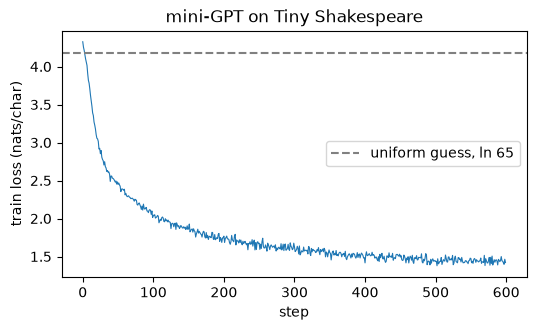

In [13]:
def train_lm(model, steps, B=32, lr=3e-3, aux_coef=0.0, log_every=100):
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.1, betas=(0.9, 0.95))
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, lr, total_steps=steps, pct_start=0.1)
    hist, t0 = [], time.time()
    for step in range(steps):
        x, y = get_batch(train_data, B, model.ctx)
        loss = F.cross_entropy(model(x).flatten(0, 1), y.flatten())
        aux = sum(getattr(b.ffn, "aux_loss", 0.0) for b in model.blocks)
        opt.zero_grad(); (loss + aux_coef * aux).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step(); sched.step()
        hist.append(loss.item())
        if step % log_every == 0 or step == steps - 1:
            print(f"step {step:4d}  train {loss.item():.3f}  val {val_loss(model):.3f}  ({time.time() - t0:.0f}s)")
    return hist

torch.manual_seed(0)
gpt = MiniGPT(vocab).to(device)
print(f"{sum(p.numel() for p in gpt.parameters()):,} parameters")
hist = train_lm(gpt, steps=600)
plt.figure(figsize=(6, 3.2)); plt.plot(hist, lw=0.8)
plt.axhline(math.log(vocab), ls="--", c="gray", label="uniform guess, ln 65")
plt.title("mini-GPT on Tiny Shakespeare"); plt.xlabel("step"); plt.ylabel("train loss (nats/char)"); plt.legend(); plt.show()

In [14]:
@torch.no_grad()
def generate(model, prompt, n=300, temperature=0.8):
    model.eval()
    idx = encode(prompt)[None].to(device)
    for _ in range(n):
        logits = model(idx[:, -model.ctx:])[:, -1] / temperature
        idx = torch.cat([idx, torch.multinomial(logits.softmax(-1), 1)], dim=1)
    model.train()
    return decode(idx[0].cpu())

torch.manual_seed(1)
print(generate(gpt, "ROMEO:\n"))

ROMEO:
O, all came the forther at your sense's life.

Servant:
I longs us, thou art trongented:
And advy to suit come
With the mild or the day suppresess for ladys
In shall eye, quarrel
Had to depeless arth the and soons endury,
And me that will I hand you: if your gatch,
Marcius Warwick land have honour a


After 600 steps (validation loss ≈ 1.63 nats/char, from 4.17) the model has the format of the play: speaker names in capitals followed by a colon, line breaks, verse-length lines, mostly real English words. The words do not form sentences yet. The scaled-up GPU setting reaches loss ≈ 1.5 with the same code.

## 4. Grouped-query attention and mixture-of-experts

**GQA.** $H$ query heads, $H_{kv}$ key/value heads; query head $h$ uses KV head $\lfloor h / (H/H_{kv}) \rfloor$. Implementation: compute $H_{kv}$ KV heads and **repeat each one** $H/H_{kv}$ times along the head axis (`repeat_kv` in the `Attention` class above, fill it in now).
$H_{kv}=H$ is MHA; $H_{kv}=1$ is multi-query attention (MQA). The KV cache shrinks by $H/H_{kv}$.
Checks: (a) with $H_{kv}=H$ our `Attention` equals the `MHA` of section 2 with the same weights; (b) with $H_{kv}<H$ it equals PyTorch's `enable_gqa=True`.

In [15]:
torch.manual_seed(0)
D, H, T = 64, 8, 10
x = torch.randn(2, T, D, dtype=torch.float64)

gqa_full = Attention(D, H, n_kv_heads=H).double()    # groups = heads
mha = MHA(D, H).double()
with torch.no_grad():
    mha.qkv.weight.copy_(torch.cat([gqa_full.wq.weight, gqa_full.wkv.weight]))   # [W_Q; W_K; W_V]
    mha.proj.weight.copy_(gqa_full.proj.weight)
print("(a) H_kv = H: max |GQA − MHA| =", (gqa_full(x)[0] - mha(x, causal_mask(T))).abs().max().item())

gqa = Attention(D, H, n_kv_heads=2).double()
q = gqa.wq(x).view(2, T, H, D // H).transpose(1, 2)
k, v = gqa.wkv(x).view(2, T, 2, 2, D // H).permute(2, 0, 3, 1, 4)
ref = F.scaled_dot_product_attention(q, k, v, is_causal=True, enable_gqa=True)
ref = gqa.proj(ref.transpose(1, 2).reshape(2, T, D))
print("(b) H_kv = 2: max |mine − SDPA(enable_gqa)| =", (gqa(x)[0] - ref).abs().max().item())
print(f"KV parameters: MHA {gqa_full.wkv.weight.numel():,}  vs  GQA(H_kv=2) {gqa.wkv.weight.numel():,}")

(a) H_kv = H: max |GQA − MHA| = 1.6653345369377348e-16
(b) H_kv = 2: max |mine − SDPA(enable_gqa)| = 0.0
KV parameters: MHA 8,192  vs  GQA(H_kv=2) 2,048


**Top-$k$ MoE.** Router logits $s = W_r x \in \mathbb{R}^E$, $p=\mathrm{softmax}(s)$. Keep the top-$k$ probabilities, renormalize them to sum to 1 (Mixtral), and output
$$y = \sum_{i \in \mathrm{TopK}(p)} g_i\, \mathrm{FFN}_i(x),\qquad g_i = \frac{p_i}{\sum_{j\in\mathrm{TopK}} p_j}.$$
Only $k$ of the $E$ experts run per token: $E/k$ times more FFN parameters at the same FLOPs.

**Load-balancing loss (Switch Transformer).** Over the $N$ tokens of a batch, $f_i$ = fraction of routing slots assigned to expert $i$, $P_i$ = mean router probability of expert $i$:
$$\mathcal{L}_{\text{aux}} = E \sum_{i=1}^{E} f_i\,P_i .$$
$f$ is not differentiable, $P$ is; the gradient pushes probability away from over-used experts. With perfectly uniform routing $f_i = P_i = 1/E$ and $\mathcal{L}_{\text{aux}}=1$.

In [16]:
class MoE(nn.Module):
    def __init__(self, d, hidden, n_experts=4, k=2):
        super().__init__()
        self.E, self.k = n_experts, k
        self.router = nn.Linear(d, n_experts, bias=False)
        self.experts = nn.ModuleList([SwiGLU(d, hidden) for _ in range(n_experts)])
        self.aux_loss, self.load = torch.tensor(0.0), None

    def forward(self, x):
        shape = x.shape
        x = x.reshape(-1, shape[-1])                                   # (N, d) tokens
        probs = self.router(x).softmax(-1)                             # (N, E)
        gates, idx = probs.topk(self.k, dim=-1)
        gates = gates / gates.sum(-1, keepdim=True)
        y = torch.zeros_like(x)
        for e, expert in enumerate(self.experts):
            tok, slot = (idx == e).nonzero(as_tuple=True)              # tokens routed to expert e
            if len(tok):
                y.index_add_(0, tok, gates[tok, slot, None] * expert(x[tok]))
        f = F.one_hot(idx, self.E).float().sum((0, 1)) / idx.numel()
        P = probs.mean(0)
        self.aux_loss = self.E * (f * P).sum()
        self.load = f.detach()
        return y.reshape(shape)

In [17]:
torch.manual_seed(0)
moe = MoE(16, 32, n_experts=4, k=2).double()
x = torch.randn(50, 16, dtype=torch.float64)
y = moe(x)
# reference: one token at a time, written directly from the formula
ref = []
for xt in x:
    p = moe.router(xt).softmax(-1); top = p.topk(2).indices
    ref.append(sum(p[i] / p[top].sum() * moe.experts[i](xt) for i in top))
print("MoE vs per-token loop: max diff =", (y - torch.stack(ref)).abs().max().item())
print("load f =", moe.load.numpy().round(3), " aux =", round(moe.aux_loss.item(), 3))

with torch.no_grad(): moe.router.weight.zero_()
moe(x)
print("uniform router (all logits 0) → aux =", round(moe.aux_loss.item(), 3))
with torch.no_grad(): moe.router.weight[0, 0], moe.router.weight[1, 0] = 1.0, 0.5   # logits (10, 5, 0, 0) when x_0 = 10
x_biased = x.clone(); x_biased[:, 0] = 10.0
moe(x_biased)
print("router collapsed onto experts 0, 1 → load f =", moe.load.numpy().round(3), " aux =", round(moe.aux_loss.item(), 3))

MoE vs per-token loop: max diff = 1.3877787807814457e-16
load f = [0.22 0.19 0.35 0.24]  aux = 1.014
uniform router (all logits 0) → aux = 1.0
router collapsed onto experts 0, 1 → load f = [0.5 0.5 0.  0. ]  aux = 2.0


Three values of $\mathcal{L}_{\text{aux}}$: a random router gives an uneven but spread load and $\mathcal{L}_{\text{aux}}\approx 1.01$; an all-zero router gives exactly 1 (top-$k$ ties break by index, so $f$ is not uniform, but $P_i=1/E$ makes $E\sum_i f_i P_i = \sum_i f_i = 1$); a router that sends every token to experts 0 and 1 with almost all its probability gives $f=(0.5,0.5,0,0)$ and $\mathcal{L}_{\text{aux}}=2=E/k$, its maximum for top-2. Experts 2 and 3 then receive no gradient at all and never recover: that is the collapse the loss prevents.

## 5. Symmetry: permutation equivariance, and how positions break it

Take one block **without the causal mask**. Permute the input tokens with a permutation $\pi$. If the block has no positional information, the output is the same set of vectors, permuted the same way: $f(x_\pi) = f(x)_\pi$. RoPE ties each token to its index, so the equality breaks. A causal mask also breaks it (token $i$ sees a different set of tokens after permuting).

In [18]:
torch.manual_seed(0)
T, D = 16, 64
blk = Block(D, 4).double()
x = torch.randn(1, T, D, dtype=torch.float64)
perm = torch.randperm(T)
rope = rope_cache(T, D // 4)

def equiv_error(**kw):
    return (blk(x[:, perm], **kw)[0] - blk(x, **kw)[0][:, perm]).abs().max().item()

print(f"no positions, no mask : max |f(x_π) − f(x)_π| = {equiv_error(rope=None, causal=False):.1e}")
print(f"RoPE,         no mask : max |f(x_π) − f(x)_π| = {equiv_error(rope=rope, causal=False):.1e}")
print(f"no positions, causal  : max |f(x_π) − f(x)_π| = {equiv_error(rope=None, causal=True):.1e}")
print(f"output scale          : mean |f(x)| = {blk(x, causal=False)[0].abs().mean().item():.2f}")
pooled = lambda z: blk(z, causal=False)[0].mean(1)
print(f"mean-pooled output, no positions: max |pool f(x_π) − pool f(x)| = {(pooled(x[:, perm]) - pooled(x)).abs().max().item():.1e}  (invariant)")

no positions, no mask : max |f(x_π) − f(x)_π| = 4.4e-16
RoPE,         no mask : max |f(x_π) − f(x)_π| = 7.0e-02
no positions, causal  : max |f(x_π) − f(x)_π| = 9.8e-01
output scale          : mean |f(x)| = 0.81
mean-pooled output, no positions: max |pool f(x_π) − pool f(x)| = 2.2e-16  (invariant)


- **No positions, no mask:** the error is ~1e-16, float64 round-off. The block is exactly permutation-equivariant, and after mean pooling exactly invariant: the model sees a **set**.
- **RoPE:** the error is ~0.07 on outputs of size ~0.8. Same tokens, different positions → different output.
- **Causal mask:** the error is ~1, larger still: after permuting, token $i$ sees a different prefix.

✏️ The trained mini-GPT has a causal mask *and* RoPE. Which of the two would already be enough for it to know word order? (Hint: run the third line above on a causal model without RoPE: "NoPE" decoders do learn order from the mask alone.)

**Past exam question (Moed C, 2026)**

True or false: in standard self-attention, reordering the input tokens (the same permutation applied to the queries, keys and values) changes the output matrix only by the same permutation of its rows.

**True** (no mask, no positional encoding). For a permutation matrix $P$: $\mathrm{softmax}\big(PQK^\top P^\top/\sqrt{d_k}\big)PV = P\,\mathrm{softmax}\big(QK^\top/\sqrt{d_k}\big)P^\top P V = P\,\mathrm{Attn}(X)$, because a row-wise softmax commutes with permuting rows and columns, and $P^\top P=I$. Self-attention is permutation-**equivariant**, the first line of the check above; a causal mask or RoPE breaks it.

In [19]:
torch.manual_seed(0)
Xp = torch.randn(1, 1, 6, 8, dtype=torch.float64)       # (B, heads, T, d)
Wq, Wk, Wv = (torch.randn(8, 8, dtype=torch.float64) for _ in range(3))
P = torch.randperm(6)
attn_of = lambda X: attention(X @ Wq, X @ Wk, X @ Wv)[0]
err = (attn_of(Xp[:, :, P]) - attn_of(Xp)[:, :, P]).abs().max().item()
print("max |Attn(PX) − P·Attn(X)| =", err)

max |Attn(PX) − P·Attn(X)| = 1.7763568394002505e-15


## 6. ViT: patchify, then a Transformer encoder

**Patchify.** An image `(B, C, H, W)` with patch size $p$ becomes `(B, N, C·p·p)` with $N = HW/p^2$, flattened in `(C, p, p)` order. A linear layer on these vectors **is** a convolution with `kernel_size = stride = p`, which is how ViT code implements it. That is the check.

In [20]:
def patchify(img, p):
    B, C, H, W = img.shape
    x = img.view(B, C, H // p, p, W // p, p).permute(0, 2, 4, 1, 3, 5)
    return x.reshape(B, (H // p) * (W // p), C * p * p)

img = torch.randn(2, 3, 32, 32, dtype=torch.float64)
conv = nn.Conv2d(3, 96, kernel_size=4, stride=4).double()
via_linear = patchify(img, 4) @ conv.weight.view(96, -1).T + conv.bias
via_conv = conv(img).flatten(2).transpose(1, 2)                 # (B, N, 96)
print("patchify shape:", tuple(patchify(img, 4).shape), "| max |linear(patchify) − conv| =", (via_linear - via_conv).abs().max().item())

patchify shape: (2, 64, 48) | max |linear(patchify) − conv| = 8.881784197001252e-16


In [21]:
class TinyViT(nn.Module):
    def __init__(self, img=32, patch=4, d=128, n_layers=4, n_heads=4, n_classes=10):
        super().__init__()
        self.p, n = patch, (img // patch) ** 2
        self.embed = nn.Linear(3 * patch * patch, d)
        self.cls = nn.Parameter(torch.zeros(1, 1, d))
        self.pos = nn.Parameter(torch.randn(1, n + 1, d) * 0.02)     # learned absolute positions
        self.blocks = nn.ModuleList([Block(d, n_heads) for _ in range(n_layers)])
        self.norm, self.head = RMSNorm(d), nn.Linear(d, n_classes)

    def forward(self, img):
        x = self.embed(patchify(img, self.p))
        x = torch.cat([self.cls.expand(len(x), -1, -1), x], dim=1) + self.pos
        for blk in self.blocks:
            x, _ = blk(x, rope=None, causal=False)                       # encoder: every patch sees every patch
        return self.head(self.norm(x[:, 0]))                             # classify from [CLS]

**Train on a CIFAR-10 subset** (10k train / 2k test images, 32×32, patch 4 → 64 tokens + [CLS]), random flips and crops, 8 epochs.
ViTs need a lot of data or strong augmentation; with 10k images a small CNN does better (for scale: ResNet-18 on the full set reaches > 90%). On a Colab GPU, use the full 50k images, 100+ epochs and RandAugment/mixup.

In [22]:
import torchvision, torchvision.transforms as Tr
mean, std = (0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)
train_tf = Tr.Compose([Tr.RandomCrop(32, padding=4), Tr.RandomHorizontalFlip(), Tr.ToTensor(), Tr.Normalize(mean, std)])
test_tf = Tr.Compose([Tr.ToTensor(), Tr.Normalize(mean, std)])
g = torch.Generator().manual_seed(0)
train_set = torch.utils.data.Subset(torchvision.datasets.CIFAR10("data", train=True, download=True, transform=train_tf), torch.randperm(50000, generator=g)[:10000])
test_set = torch.utils.data.Subset(torchvision.datasets.CIFAR10("data", train=False, download=True, transform=test_tf), torch.randperm(10000, generator=g)[:2000])
train_loader = torch.utils.data.DataLoader(train_set, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=500)

@torch.no_grad()
def accuracy(model):
    model.eval()
    correct = sum((model(x.to(device)).argmax(-1).cpu() == y).sum().item() for x, y in test_loader)
    model.train(); return correct / len(test_set)

torch.manual_seed(0)
vit = TinyViT().to(device)
epochs = 8
opt = torch.optim.AdamW(vit.parameters(), lr=1e-3, weight_decay=0.05)
sched = torch.optim.lr_scheduler.OneCycleLR(opt, 1e-3, total_steps=epochs * len(train_loader), pct_start=0.15)
print(f"{sum(p.numel() for p in vit.parameters()):,} parameters")
t0, accs = time.time(), []
for ep in range(epochs):
    for xb, yb in train_loader:
        loss = F.cross_entropy(vit(xb.to(device)), yb.to(device))
        opt.zero_grad(); loss.backward(); opt.step(); sched.step()
    accs.append(accuracy(vit))
    print(f"epoch {ep + 1}  train loss {loss.item():.3f}  test acc {accs[-1]:.3f}  ({time.time() - t0:.0f}s)")

869,130 parameters


epoch 1  train loss 1.811  test acc 0.298  (7s)


epoch 2  train loss 2.205  test acc 0.352  (14s)


epoch 3  train loss 1.457  test acc 0.412  (20s)


epoch 4  train loss 1.572  test acc 0.449  (27s)


epoch 5  train loss 1.226  test acc 0.521  (33s)


epoch 6  train loss 1.084  test acc 0.512  (41s)


epoch 7  train loss 1.351  test acc 0.542  (48s)


epoch 8  train loss 1.185  test acc 0.548  (55s)


What did the learned position embeddings learn? Cosine similarity between the embedding of one patch position and all 64 positions, shown on the 8×8 patch grid.

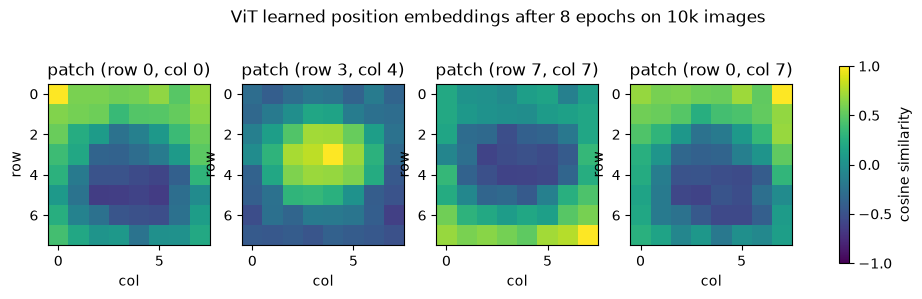

In [23]:
pos = F.normalize(vit.pos[0, 1:].detach().cpu(), dim=-1)          # (64, d), skip [CLS]
sim = (pos @ pos.T).view(64, 8, 8)
fig, axes = plt.subplots(1, 4, figsize=(12, 3.2))
for ax, (r, c) in zip(axes, [(0, 0), (3, 4), (7, 7), (0, 7)]):
    im = ax.imshow(sim[r * 8 + c], cmap="viridis", vmin=-1, vmax=1)
    ax.set_title(f"patch (row {r}, col {c})"); ax.set_xlabel("col"); ax.set_ylabel("row")
fig.colorbar(im, ax=axes, shrink=0.8, label="cosine similarity")
fig.suptitle(f"ViT learned position embeddings after {epochs} epochs on 10k images")
plt.show()

Each position embedding is most similar to itself and to its spatial neighbours: the corner patches match their own row and column edge, the centre patch a blob around the centre. Nothing told the model the patches lie on a 2D grid (positions are just indices 0–63); it learned the 2D layout from 10k images in 8 epochs. Test accuracy is ≈ 55% on 2k images, far below a CNN on the same data: the lecture's point that ViTs lack the locality prior and must learn it from data.

**Past exam question (Moed C, 2026)**

In a Vision Transformer (ViT) the image is split into fixed-size patches (e.g. $16\times16$); each patch is flattened into a vector and used as a token, and a learned positional embedding is added to every token.

Explain why ViT needs positional embeddings while a standard CNN does not. Refer explicitly to the nature of the self-attention operation and to the convolution operation along the spatial dimensions.

Self-attention treats its input as a **set**: it is permutation-equivariant (previous section), and with [CLS] or mean pooling the prediction is permutation-invariant. Without position embeddings, shuffling the patches gives exactly the same output, so the model cannot tell where a patch was, nor which patches are neighbours. The embeddings attach each token's location to its content. A convolution is defined on the 2-D grid: each output combines a fixed $K\times K$ neighbourhood, and the weight of each neighbour is tied to its relative offset, so the spatial layout (locality and relative position) is built into the operation, and stacked layers plus pooling turn it into global position. Check below: with its position embeddings removed, our trained TinyViT gives identical logits (up to float32 round-off) for an image and its patch-shuffled version; with them, the logits change by up to ~3. Accuracy on shuffled images, however, stays at ≈ 0.50: after 8 epochs on 10k images this small ViT classifies mostly from the bag of patch contents and has learned little use of their layout, the same missing locality prior as above.

In [24]:
@torch.no_grad()
def vit_logits(model, img, perm=None, use_pos=True):
    x = model.embed(patchify(img, model.p))
    if perm is not None:
        x = x[:, perm]                                  # shuffle the patches
    x = torch.cat([model.cls.expand(len(x), -1, -1), x], dim=1)
    if use_pos:
        x = x + model.pos
    for blk in model.blocks:
        x, _ = blk(x, rope=None, causal=False)
    return model.head(model.norm(x[:, 0]))

vit.eval()
imgs, labels = next(iter(test_loader))
imgs = imgs.to(device)
perm = torch.randperm(64, generator=torch.Generator().manual_seed(0)).to(device)
diff_nopos = (vit_logits(vit, imgs, perm, use_pos=False) - vit_logits(vit, imgs, use_pos=False)).abs().max().item()
diff_pos = (vit_logits(vit, imgs, perm) - vit_logits(vit, imgs)).abs().max().item()
acc_orig = (vit_logits(vit, imgs).argmax(-1).cpu() == labels).float().mean().item()
acc_shuf = (vit_logits(vit, imgs, perm).argmax(-1).cpu() == labels).float().mean().item()
vit.train()
print(f"no position embeddings: max |Δ logits| after shuffling = {diff_nopos:.1e}")
print(f"with position embeddings: max |Δ logits| after shuffling = {diff_pos:.2f}")
print(f"accuracy on {len(labels)} test images: original {acc_orig:.3f}, patch-shuffled {acc_shuf:.3f}")

no position embeddings: max |Δ logits| after shuffling = 1.8e-06
with position embeddings: max |Δ logits| after shuffling = 3.40
accuracy on 500 test images: original 0.502, patch-shuffled 0.496


## 7. Inside the trained mini-GPT: logit lens and attention sinks

**Logit lens** (nostalgebraist, 2020). The residual stream after every block has the same shape as the final one. Apply the model's own final norm and unembedding to it, $\ \mathrm{softmax}(W_U\,\mathrm{RMSNorm}(x^{(\ell)}))$, and read it as a next-character prediction. Question: at which layer does the right next character appear?

max |last lens layer − model logits| = 2.0623207092285156e-05


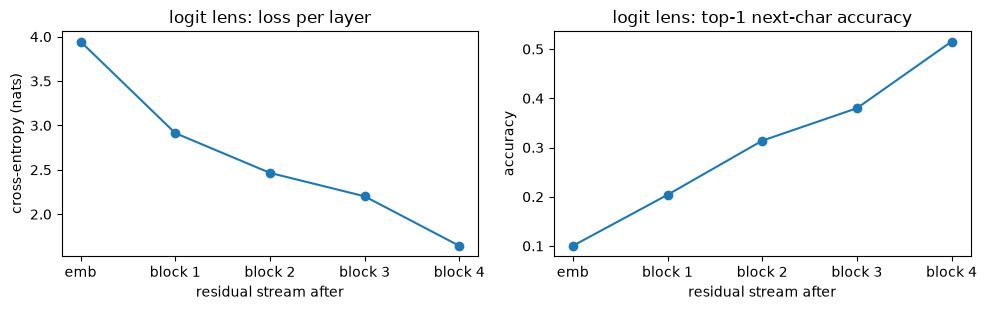

emb      loss 3.94  acc 0.100
block 1  loss 2.91  acc 0.204
block 2  loss 2.47  acc 0.314
block 3  loss 2.20  acc 0.380
block 4  loss 1.64  acc 0.515


In [25]:
@torch.no_grad()
def logit_lens(model, x):
    _, resid, _ = model(x, return_internals=True)
    return [model.head(model.norm(r)) for r in resid]

torch.manual_seed(0)
gpt.eval()
xv, yv = get_batch(val_data, 64, gpt.ctx)
lens = logit_lens(gpt, xv)
print("max |last lens layer − model logits| =", (lens[-1] - gpt(xv)).abs().max().item())
lens_loss = [F.cross_entropy(l.flatten(0, 1), yv.flatten()).item() for l in lens]
lens_acc = [(l.argmax(-1) == yv).float().mean().item() for l in lens]
names = ["emb"] + [f"block {i + 1}" for i in range(len(gpt.blocks))]
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].plot(names, lens_loss, marker="o"); ax[0].set(title="logit lens: loss per layer", xlabel="residual stream after", ylabel="cross-entropy (nats)")
ax[1].plot(names, lens_acc, marker="o"); ax[1].set(title="logit lens: top-1 next-char accuracy", xlabel="residual stream after", ylabel="accuracy")
plt.tight_layout(); plt.show()
for n, l, a in zip(names, lens_loss, lens_acc): print(f"{n:8s} loss {l:.2f}  acc {a:.3f}")

The same view on one line of text: the top prediction at every position, decoded from each layer. Read each column top to bottom.

In [26]:
prompt = "To be, or not to be, that is the question"
xs = encode(prompt)[None].to(device)
rows = [l[0].argmax(-1).cpu() for l in logit_lens(gpt, xs)]

show = lambda s: " ".join("_" if c == " " else ("⏎" if c == "\n" else c) for c in s)
print(f"{'input':>9}: " + show(prompt))
print(f"{'target':>9}: " + show(prompt[1:]) + " ?")
for n, r in zip(names, rows):
    print(f"{n:>9}: " + show(decode(r)))

    input: T o _ b e , _ o r _ n o t _ t o _ b e , _ t h a t _ i s _ t h e _ q u e s t i o n
   target: o _ b e , _ o r _ n o t _ t o _ b e , _ t h a t _ i s _ t h e _ q u e s t i o n ?
      emb: E u b h r i b u e b g u h b h u b h r i b h i i h b c y b h i r b u t r y h c u g
  block 1: o w t e r _ t w e t g w _ t h w t e r _ t h y t _ t t t t h y r t u t r t _ n u g
  block 2: h n m e n _ t r _ t o w _ t h r t u n _ t h e t _ t t _ t h e r t u s s t _ n n _
  block 3: h _ t y _ ⏎ a r _ t o w _ t h o t e _ ⏎ a h e t _ s t _ t h e _ s u t s t _ n n ,
  block 4: h _ m e _ _ a r _ t o t _ t h _ t e _ ⏎ a h e t _ t s _ t h e _ s u e e t , n n ⏎


- The loss falls at every layer (3.94 → 2.91 → 2.47 → 2.20 → 1.64) and top-1 accuracy rises from 0.10 to 0.52. The prediction is built up gradually in the residual stream, and the last block contributes the largest single drop.
- In the example, bigram-like completions appear early: after `T` the `o` is there from block 1, after `t` the `h` from block 1. Completions that need the whole word are late: the space after `To` appears only at block 3, the `e` of `the` only at block 2.
- The final rows still miss characters that need context beyond the current word (the `?` after `question`): a 4-layer char model has little room for that.

**Attention sinks** (Xiao et al., 2023, StreamingLLM). Trained LMs put a large share of attention on the **first token**, whatever it is: softmax weights must sum to 1, so a head with nothing useful to read parks its mass on a token every query can see. Measure it: for queries at positions $t \ge 32$, the mean weight on key 0, per layer and head. A head that attended uniformly over its causal window would give the average of $\frac{1}{t+1}$, ≈ 0.014 here.
Our training windows start at random positions, so position 0 is an arbitrary character, never a BOS token.

In [27]:
@torch.no_grad()
def first_token_mass(attns, t_min=32):
    # attns: list over layers of (B, H, T, T) attention weights → (layers, heads)
    return torch.stack([w[:, :, t_min:, 0].float().mean((0, 2)) for w in attns]).cpu()

def plot_sink(ax, sink, title, annotate=True):
    im = ax.imshow(sink, cmap="magma", vmin=0, vmax=1, aspect="auto")
    if annotate:
        for (l, h), val in np.ndenumerate(sink.numpy()): ax.text(h, l, f"{val:.2f}", ha="center", va="center", color="w" if val < 0.5 else "k")
    ax.set(title=title, xlabel="head", ylabel="layer")
    return im

uniform = (1 / torch.arange(33, gpt.ctx + 1).float()).mean().item()
with torch.no_grad():
    sink_gpt = first_token_mass(gpt(xv, return_internals=True)[2])
print(f"uniform baseline {uniform:.3f} | mini-GPT: mean {sink_gpt.mean():.3f}, max {sink_gpt.max():.3f}")

uniform baseline 0.014 | mini-GPT: mean 0.003, max 0.009


For comparison, the same measurement on a real LM with the 2026 block: **SmolLM2-135M** (30 layers, 9 query heads, 3 KV heads (GQA), RMSNorm, SwiGLU, RoPE, trained on ~2T tokens). We feed it 128 BPE tokens of Tiny Shakespeare from the middle of a line, without a BOS token, and ask for the attention weights (`attn_implementation="eager"`; the fused kernels do not return them). ≈ 270 MB download.

/private/tmp/claude-501/-Users-idanschwartz-Library-CloudStorage-OneDrive-BarIlanUniversity-playground/bb5fb5c5-72a5-41d3-b3fc-41e1b89dd2e2/scratchpad/tut/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 3712.45it/s]

first token: 'or' | config: 30 layers, 9 heads, 3 KV heads


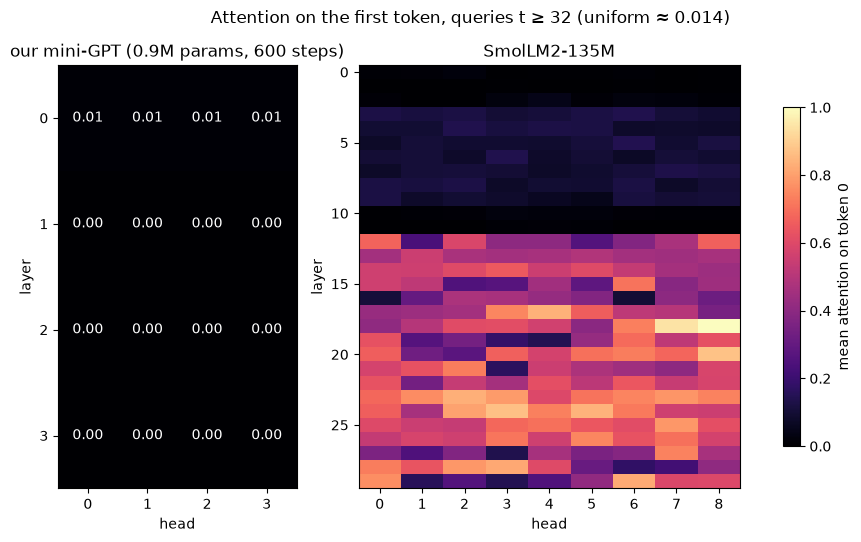

SmolLM2 layers 0-2: mean attention on token 0 = 0.01
SmolLM2 layers 3-11: mean attention on token 0 = 0.08
SmolLM2 layers 12-29: mean attention on token 0 = 0.53


In [28]:
from transformers import AutoTokenizer, AutoModelForCausalLM
tok = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolLM2-135M")
lm = AutoModelForCausalLM.from_pretrained("HuggingFaceTB/SmolLM2-135M", attn_implementation="eager", dtype=torch.float32).eval()
ids = tok(text[5000:6000], return_tensors="pt").input_ids[:, :128]
print("first token:", repr(tok.decode(ids[0, :1])), "| config:", lm.config.num_hidden_layers, "layers,",
      lm.config.num_attention_heads, "heads,", lm.config.num_key_value_heads, "KV heads")
with torch.no_grad():
    sink_lm = first_token_mass(lm(ids, output_attentions=True).attentions)

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5), gridspec_kw={"width_ratios": [1, 1.6]})
plot_sink(axes[0], sink_gpt, "our mini-GPT (0.9M params, 600 steps)")
axes[0].set_yticks(range(len(gpt.blocks)))
im = plot_sink(axes[1], sink_lm, "SmolLM2-135M", annotate=False)
fig.colorbar(im, ax=axes, label="mean attention on token 0", shrink=0.8)
fig.suptitle(f"Attention on the first token, queries t ≥ 32 (uniform ≈ {uniform:.3f})")
plt.show()
for lo, hi in [(0, 3), (3, 12), (12, 30)]:
    print(f"SmolLM2 layers {lo}-{hi - 1}: mean attention on token 0 = {sink_lm[lo:hi].mean():.2f}")

- **Our mini-GPT has no sink:** every head puts ≈ the uniform share or less on token 0.
- **SmolLM2 does, from the middle of the network on:** in layers 0–11 token 0 gets 1–8% of the attention on average; in layers 12–29 it gets 53% on average, close to 100% in one head of layer 18, although token 0 here is the arbitrary word piece `or`. A few upper-layer heads stay below 20%: those are the heads that still read the context. The rest spend most of their attention on a token that carries no information for the query.
- This is why StreamingLLM keeps the first few tokens in the KV cache when it slides a window: evict them and the softmax mass has nowhere to go, and the model breaks. Sinks are a property of large, long-trained models; a 0.9M-parameter model after 600 steps does not show it (the cheap test: the same measurement on our model after 5000 steps on a GPU).

✏️ Is the sink about **position** or **content**? Replace the first token of `ids` by another one (e.g. `ids2 = ids.clone(); ids2[0, 0] = tok(" the").input_ids[0]`), and also drop it (`ids[:, 1:]`), then re-measure. Then plot `attentions[l][0, h, -1]` for a strong sink head: what else does it attend to?

## 8. If time: the MoE mini-GPT, with and without the balancing loss

Replace every SwiGLU in the mini-GPT by an `MoE` with 4 experts, top-2, each expert half the hidden size (same active FFN parameters per token as the dense model). Train two copies for 200 steps: $\alpha=0$ and $\alpha=0.01$ on $\sum_\ell \mathcal{L}_{\text{aux}}^{(\ell)}$. Compare the expert load.

--- aux coefficient 0.0 ---


step    0  train 4.387  val 4.354  (1s)


step  199  train 1.800  val 1.919  (87s)
aux per layer: [1.116, 1.102, 1.092, 1.027]
--- aux coefficient 0.01 ---


step    0  train 4.387  val 4.354  (0s)


step  199  train 1.801  val 1.915  (30s)
aux per layer: [1.002, 1.0, 1.016, 1.004]


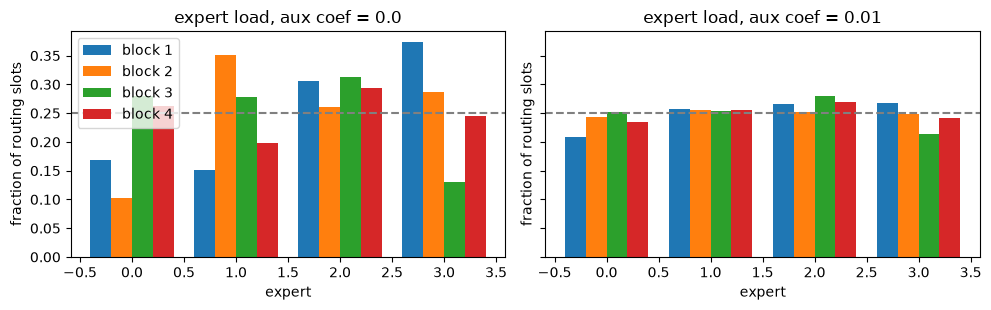

In [29]:
def moe_gpt():
    return MiniGPT(vocab, ffn_fn=lambda: MoE(128, 192, n_experts=4, k=2)).to(device)

loads = {}
for coef in (0.0, 0.01):
    torch.manual_seed(0)
    m = moe_gpt()
    print(f"--- aux coefficient {coef} ---")
    train_lm(m, steps=200, aux_coef=coef, log_every=199)
    with torch.no_grad(): m(xv)
    loads[coef] = torch.stack([b.ffn.load for b in m.blocks]).cpu()
    print("aux per layer:", [round(b.ffn.aux_loss.item(), 3) for b in m.blocks])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), sharey=True)
for ax, (coef, ld) in zip(axes, loads.items()):
    for l in range(ld.shape[0]): ax.bar(np.arange(4) + 0.2 * (l - 1.5), ld[l], width=0.2, label=f"block {l + 1}")
    ax.axhline(0.25, c="gray", ls="--"); ax.set(title=f"expert load, aux coef = {coef}", xlabel="expert", ylabel="fraction of routing slots")
axes[0].legend(); plt.tight_layout(); plt.show()

Without the balancing loss the routers are already uneven after 200 steps: loads range from 10% to 37% of the slots, and $\mathcal{L}_{\text{aux}}$ is 1.03–1.12. With $\alpha=0.01$ every load is within 21–28% and $\mathcal{L}_{\text{aux}}\le 1.02$, at the same validation loss (1.92 in both runs). At this scale nothing collapses; in large models an unbalanced router overloads some devices and starves others, which is why every MoE recipe uses either this loss or DeepSeek-V3's per-expert bias.

## Summary
- Attention is a data-dependent weighted average: $\mathrm{softmax}(QK^\top/\sqrt d)V$. Our version matches `F.scaled_dot_product_attention` and `nn.MultiheadAttention` to ~1e-16 in float64.
- The 2026 block changes only parts of the 2017 one: pre-norm with RMSNorm, SwiGLU, RoPE on $q,k$, GQA. Each piece is a few lines; RoPE's check is that the score depends only on the offset.
- GQA is MHA with KV heads repeated; MoE is a router + top-$k$ + a balancing loss $E\sum_i f_iP_i$ that equals 1 when the experts are evenly used.
- Without positions a Transformer block is permutation-equivariant (error ~1e-16); RoPE or a causal mask breaks the symmetry, and that is the only way the model knows token order.
- ViT = patchify (a strided convolution) + the same encoder blocks. On 10k CIFAR images it is data-starved; the learned position embeddings are where the 2D structure has to come from.
- Inside the mini-GPT, the logit lens shows the next-character prediction forming layer by layer. Attention sinks (most of a head's attention on the first token) are absent in our small model and present in most upper layers of SmolLM2-135M.

**Further watching:** 3Blue1Brown, [*Transformers, the tech behind LLMs* (ch. 5)](https://www.youtube.com/watch?v=wjZofJX0v4M) and [*Attention in transformers, step-by-step* (ch. 6)](https://www.youtube.com/watch?v=eMlx5fFNoYc); Karpathy, [*Let's build GPT: from scratch, in code, spelled out*](https://www.youtube.com/watch?v=kCc8FmEb1nY) (section 3 follows it, with the 2026 block); Umar Jamil, [*Attention is all you need (Transformer): model explanation, math, inference and training*](https://www.youtube.com/watch?v=bCz4OMemCcA).

**Further reading:** Stanford CME 295 (2025), [Lecture 1: the Transformer](https://cme295.stanford.edu/slides/fall25-cme295-lecture1.pdf) and [Lecture 2: MHA/MQA/GQA, RoPE](https://cme295.stanford.edu/slides/fall25-cme295-lecture2.pdf).